In [55]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from env_vars import CACHE_DIR
import ujson
import collections
import heapq
import copy
import matplotlib.pyplot as plt

In [4]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B", cache_dir=CACHE_DIR)

In [41]:
data = []
with open('/cmlscratch/snawathe/cmsc828g-proj/results/inference_qwen3-4b_math500_G8_B16384_chunk0.jsonl', 'r') as f:
	for line in f.readlines():
		data.append(ujson.loads(line))

In [14]:
len(data[0]['method_output']['outputs'][0]['token_ids'])

1483

In [17]:
sample_to_len_data = collections.defaultdict(list)
for sample in data:
	sample_to_len_data[sample['sample_idx']].extend(list(map(lambda x: len(x['token_ids']), sample['method_output']['outputs'])))

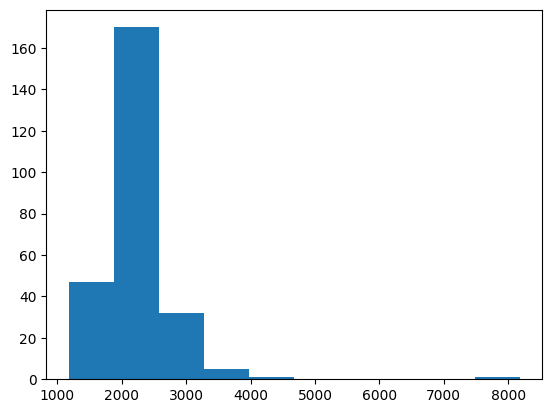

In [27]:
plt.hist(sample_to_len_data[5])
plt.show()

In [42]:
group_lens = []
for group_data in data:
	group_lens.append(list(map(lambda x: len(x['token_ids']), group_data['method_output']['outputs'])))

In [48]:
gmax = list(map(max, group_lens))
gsum = list(map(sum, group_lens))

In [44]:
gtimes = []
for group_data in data:
	gtimes.append(group_data['generation_time'])

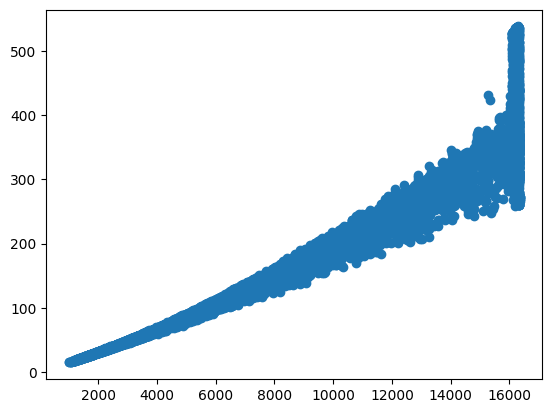

In [46]:
plt.scatter(gmax, gtimes)
plt.show()

In [51]:
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(gmax, gtimes)
print(f"Slope: {slope}")
print(f"R^2: {r_value**2}")

Slope: 0.024983639905050016
R^2: 0.9303682698406862


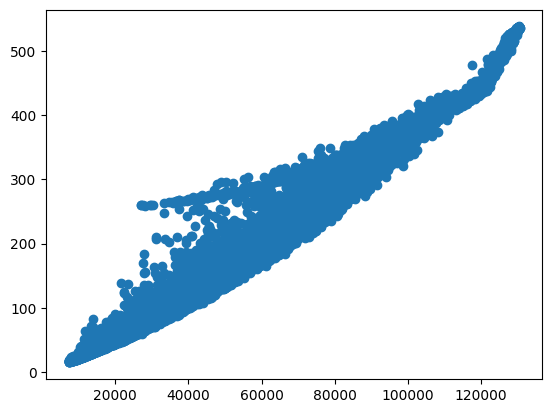

In [47]:
plt.scatter(gsum, gtimes)
plt.show()

In [52]:
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(gsum, gtimes)
print(f"Slope: {slope}")
print(f"R^2: {r_value**2}")

Slope: 0.0040366546104690084
R^2: 0.9684497638017225


In [57]:
def compute_epoch_time_for_ordering(order: list[int], epoch_data: dict[int, list[int]], num_nodes: int) -> int:
	assert set(order) == set(epoch_data.keys())
	times = [max(epoch_data[idx]) for idx in order]
	heap = []
	for _ in range(num_nodes):
		heapq.heappush(heap, times[0])
		times.pop(0)
	t = 0
	while heap:
		t = heapq.heappop(heap)
		if times:
			heapq.heappush(heap, t + times[0])
			times.pop(0)
	return t


def compute_time_for_ordering(order: list[int], sample_to_len_data: dict[int, list[int]], G: int, num_nodes: int) -> int:
	assert set(order) == set(sample_to_len_data.keys())
	sample_to_len_data = copy.deepcopy(sample_to_len_data)
	total_len = len(sample_to_len_data[0])
	tot_time = 0
	for _ in range(0, total_len, G):
		epoch_data = {}
		for k, v in sample_to_len_data.items():
			epoch_data[k] = v[:G]
			sample_to_len_data[k] = v[G:]
		tot_time += compute_epoch_time_for_ordering(order, epoch_data, num_nodes)
	return tot_time

In [86]:
sample_to_len_data_copy = copy.deepcopy(sample_to_len_data)
epoch_data = {}
for k, v in sample_to_len_data.items():
	epoch_data[k] = v[:8]
	sample_to_len_data[k] = v[8:]

In [87]:
epoch_data

{0: [1676, 1679, 1698, 1625, 1649, 1658, 1259, 1862],
 1: [7660, 5595, 5505, 3392, 5622, 7563, 6322, 4524],
 2: [2652, 2620, 2747, 2818, 2627, 2634, 2134, 2786],
 3: [1767, 2264, 2420, 2435, 1877, 1911, 1944, 2094],
 4: [3603, 3661, 3123, 5830, 4291, 3106, 4951, 5692],
 5: [2109, 2148, 2894, 2152, 3171, 1524, 1995, 1739],
 6: [3434, 3054, 3367, 3003, 3427, 3310, 2794, 3190],
 7: [3081, 3460, 3585, 3523, 2814, 2668, 4194, 3908],
 8: [1732, 1650, 1446, 1884, 1448, 1556, 1806, 1267],
 9: [12232, 16211, 16211, 16211, 14442, 16211, 16211, 16211],
 10: [9942, 5931, 7103, 7239, 7856, 5995, 6822, 9300],
 11: [8315, 6709, 8405, 9829, 7975, 12344, 9536, 7751],
 12: [3732, 3844, 3876, 3833, 4157, 3564, 3998, 3560],
 13: [1068, 879, 1216, 1130, 1770, 2051, 1283, 2383],
 14: [2290, 2687, 2478, 2467, 2289, 2227, 2510, 2679],
 15: [3063, 4494, 4593, 4978, 4535, 4121, 5225, 5161],
 16: [2772, 2904, 4313, 2600, 2965, 2198, 3031, 3411],
 17: [6555, 4016, 6755, 5829, 6251, 6364, 5051, 5820],
 18: [14989,

In [88]:
compute_time_for_ordering(sorted(list(sample_to_len_data.keys())), sample_to_len_data, G=8, num_nodes=8)

11046426

In [67]:
idx_to_mean = {k: sum(v) / len(v) for k, v in sample_to_len_data.items()}
tups = [(mean, idx) for idx, mean in idx_to_mean.items()]
tups.sort()
asc_ordering = [idx for mean, idx in tups]
desc_ordering = asc_ordering[::-1]

In [89]:
compute_time_for_ordering(asc_ordering, sample_to_len_data, G=8, num_nodes=8)

11034849

In [91]:
11034849 / 11046426

0.998951968718208

In [90]:
compute_time_for_ordering(desc_ordering, sample_to_len_data, G=8, num_nodes=8)

10873658

In [92]:
10873658 / 11046426

0.984359828237658